# Cardiovascular Risk Detection — Early Identification System

**Dataset:** Cardiovascular Disease Dataset (~70,000 patient records)  
**Problem Type:** Binary Classification (cardiovascular disease: yes/no)  
**Main Metric:** AUC-ROC  

---

## Table of Contents

1. [Environment Setup](#1-environment-setup)
2. [Data Loading and Initial Inspection](#2-data-loading-and-initial-inspection)
3. [Exploratory Data Analysis](#3-exploratory-data-analysis)
4. [Outlier Detection and Removal](#4-outlier-detection-and-removal)
5. [Feature Engineering](#5-feature-engineering)
6. [Preprocessing Pipeline](#6-preprocessing-pipeline)
7. [Model Training and Evaluation](#7-model-training-and-evaluation)
8. [Model Comparison and ROC Analysis](#8-model-comparison-and-roc-analysis)
9. [Cost-Sensitive Evaluation and Threshold Optimization](#9-cost-sensitive-evaluation-and-threshold-optimization)
10. [Probability Calibration Analysis](#10-probability-calibration-analysis)
11. [Explainability — SHAP Analysis](#11-explainability--shap-analysis)
12. [Robustness Testing](#12-robustness-testing)
13. [Uncertainty Quantification](#13-uncertainty-quantification)
14. [Optimized Decision Policy](#14-optimized-decision-policy)
15. [Causal Reasoning and Confounding](#15-causal-reasoning-and-confounding)
16. [Temporal Extension and Survival Analysis Framing](#16-temporal-extension-and-survival-analysis-framing)
17. [System Architecture Diagram](#17-system-architecture-diagram)
18. [Clinical Decision Policy (Tier Mapping)](#18-clinical-decision-policy-tier-mapping)
19. [Feature Importance](#19-feature-importance)
20. [Final Predictions](#20-final-predictions)
21. [Failure Mode Analysis and Deployment Considerations](#21-failure-mode-analysis-and-deployment-considerations)
22. [Conclusions](#22-conclusions)


---
## 1. Environment Setup

Importing all needed libraries upfront. Seeds are fixed so results stay reproducible across runs — important since we're using bootstrap and cross-validation later.


In [1]:
import copy
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
from sklearn.base import clone


from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    roc_auc_score, roc_curve, classification_report,
    confusion_matrix, ConfusionMatrixDisplay, accuracy_score,
    brier_score_loss
)
from sklearn.calibration import calibration_curve, CalibratedClassifierCV
from sklearn.impute import SimpleImputer
from sklearn.utils import resample

import lightgbm as lgb
import shap

warnings.filterwarnings('ignore')


plt.rcParams['figure.figsize'] = (6, 3)
plt.rcParams['figure.dpi'] = 80


---
## 2. Data Loading and Initial Inspection

File uses semicolons as delimiter. Age is stored in days so converting to years right away. The `id` column is just a row identifier — dropping it.


In [2]:
df = pd.read_csv('cardio_train.csv', sep=';')

# age is in days — convert to years
df['age'] = (df['age'] / 365.25).round(1)

df.drop(columns=['id'], inplace=True)

print(f"Shape          : {df.shape}")
print(f"Target counts  : {df['cardio'].value_counts().to_dict()}")
print(f"Missing values : {df.isnull().sum().sum()}")
df.head()


Shape          : (70000, 12)
Target counts  : {0: 35021, 1: 34979}
Missing values : 0


,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,50.4,2,168,62.0,110,80,1,1,0,0,1,0
1,55.4,1,156,85.0,140,90,3,1,0,0,1,1
2,51.6,1,165,64.0,130,70,3,1,0,0,0,1
3,48.2,2,169,82.0,150,100,1,1,0,0,1,1
4,47.8,1,156,56.0,100,60,1,1,0,0,0,0


In [3]:
df.describe()


,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
count,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000
mean,53.302913,1.349571,164.359229,74.205690,128.817286,96.630414,1.366871,1.226457,0.088129,0.053771,0.803729,0.499700
std,6.755126,0.476838,8.210126,14.395757,154.011419,188.472530,0.680250,0.572270,0.283484,0.225568,0.397179,0.500003
min,29.600000,1.000000,55.000000,10.000000,-150.000000,-70.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,48.400000,1.000000,159.000000,65.000000,120.000000,80.000000,1.000000,1.000000,0.000000,0.000000,1.000000,0.000000
50%,53.900000,1.000000,165.000000,72.000000,120.000000,80.000000,1.000000,1.000000,0.000000,0.000000,1.000000,0.000000
75%,58.400000,2.000000,170.000000,82.000000,140.000000,90.000000,2.000000,1.000000,0.000000,0.000000,1.000000,1.000000
max,64.900000,2.000000,250.000000,200.000000,16020.000000,11000.000000,3.000000,3.000000,1.000000,1.000000,1.000000,1.000000


**Initial observations:**

- `ap_hi` and `ap_lo` clearly have bad entries — negative pressures and readings over 400 mmHg are physiologically impossible. Need to filter those out.
- The target (`cardio`) is roughly 50/50 split, which is nice — no need to worry about class imbalance.
- Age after conversion sits between ~29 and 65 years.


---
## 3. Exploratory Data Analysis

### 3.1 Target Distribution


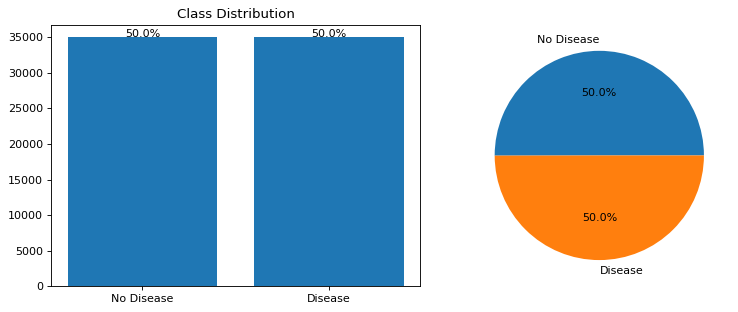

Balanced dataset


In [4]:
fig, ax = plt.subplots(1, 2, figsize=(10, 4))

counts = df['cardio'].value_counts().sort_index()

ax[0].bar(['No Disease', 'Disease'], counts.values)
ax[0].set_title('Class Distribution')

for i, v in enumerate(counts.values):
    ax[0].text(i, v, f'{v/len(df)*100:.1f}%', ha='center')

ax[1].pie(counts.values, labels=['No Disease', 'Disease'], autopct='%1.1f%%')

plt.tight_layout()
plt.show()

print("Balanced dataset")

### 3.2 Distribution of Continuous Features


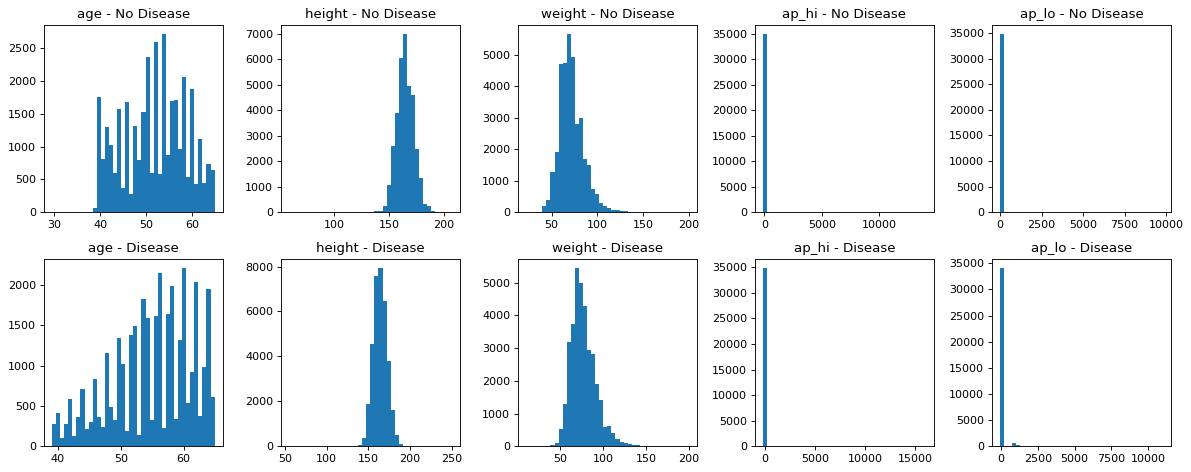

In [5]:
continuous_cols = ['age', 'height', 'weight', 'ap_hi', 'ap_lo']

fig, ax = plt.subplots(2, len(continuous_cols), figsize=(15, 6))

for i, col in enumerate(continuous_cols):
    ax[0, i].hist(df[df['cardio'] == 0][col], bins=40)
    ax[0, i].set_title(f'{col} - No Disease')
    
    ax[1, i].hist(df[df['cardio'] == 1][col], bins=40)
    ax[1, i].set_title(f'{col} - Disease')

plt.tight_layout()
plt.show()

The blood pressure columns (`ap_hi`, `ap_lo`) have visible extreme outliers. Age and weight both show decent separation between the two classes, which suggests they'll be useful predictors.


### 3.3 Categorical Feature Analysis


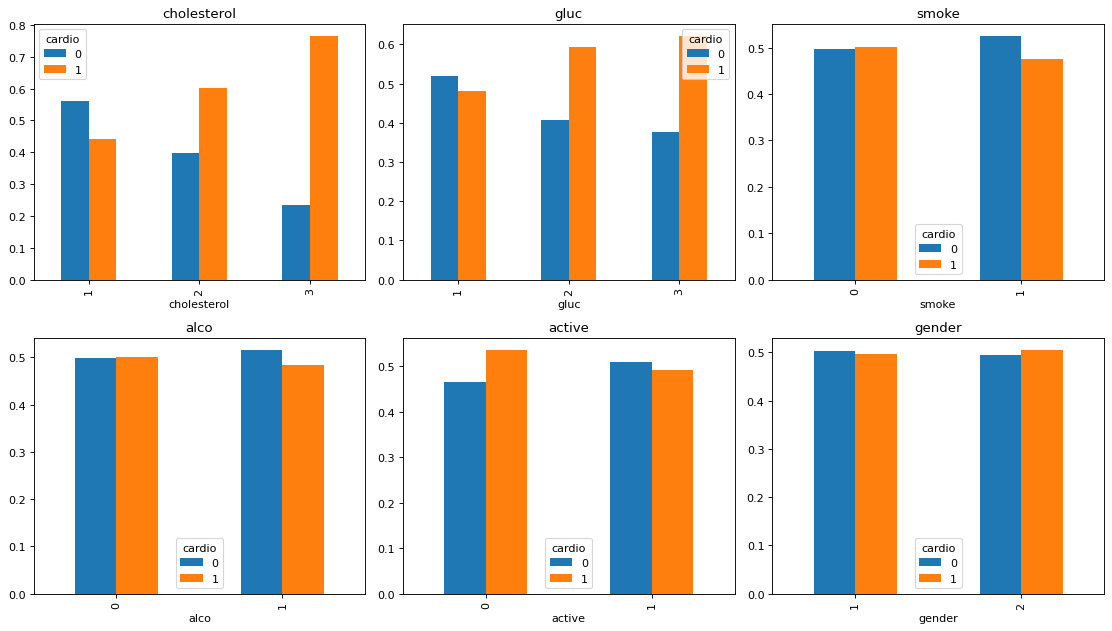

In [6]:
cat_cols = ['cholesterol', 'gluc', 'smoke', 'alco', 'active', 'gender']

fig, ax = plt.subplots(2, 3, figsize=(14, 8))
ax = ax.flatten()

for i, col in enumerate(cat_cols):
    ct = pd.crosstab(df[col], df['cardio'], normalize='index')
    ct.plot(kind='bar', ax=ax[i])
    ax[i].set_title(col)

plt.tight_layout()
plt.show()

**What stands out:**
- Higher cholesterol and glucose levels are clearly associated with disease — makes sense clinically.
- Smoking and alcohol have weak associations here, probably because this is synthetic data.
- Active patients show slightly lower disease rates, though causality is hard to establish (reverse causality is a real concern).


### 3.4 Correlation Heatmap


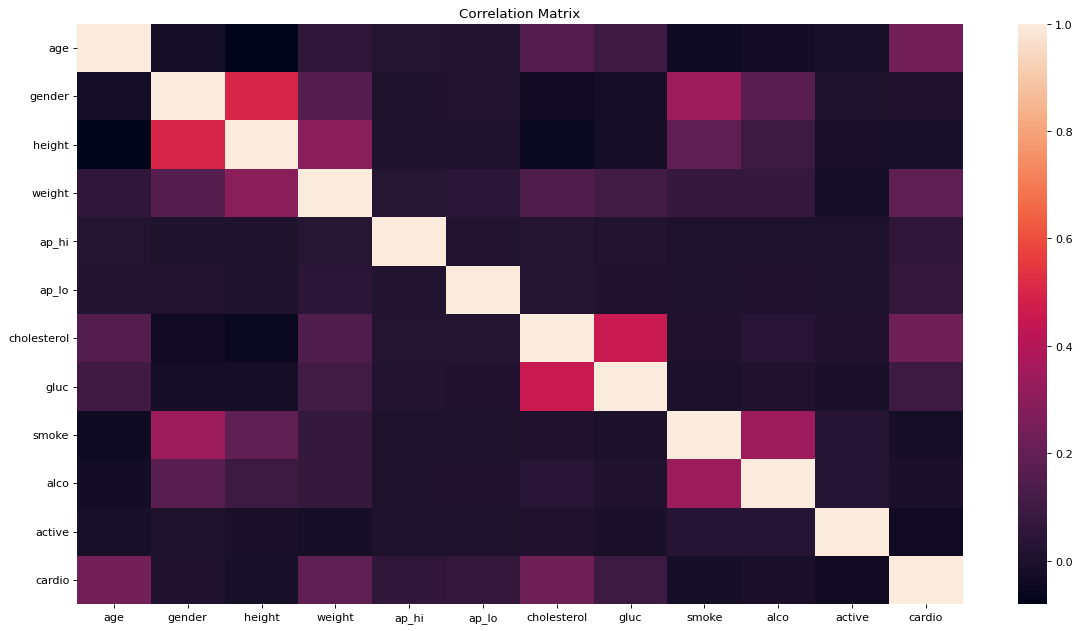

In [7]:
fig, ax = plt.subplots(figsize=(15, 8))

corr = df.corr()

sns.heatmap(corr, ax=ax)

ax.set_title('Correlation Matrix')
plt.tight_layout()
plt.show()

**Notable correlations with `cardio`:**
- `ap_hi` and `ap_lo` have the strongest positive correlation with the target.
- `cholesterol` is moderately correlated — aligns with what we'd expect.
- `age` shows a clear positive trend, consistent with real cardiovascular risk patterns.
- `ap_hi` and `ap_lo` are highly correlated with each other, which is expected and motivates deriving `pulse_pressure` as a separate feature.


---
## 4. Outlier Detection and Removal

Blood pressure is the main problem area. Applying clinically plausible bounds based on standard medical guidelines:

- **Systolic (ap_hi):** 70–250 mmHg
- **Diastolic (ap_lo):** 40–200 mmHg
- **Constraint:** systolic must be strictly greater than diastolic
- **Height:** 100–220 cm
- **Weight:** 30–200 kg


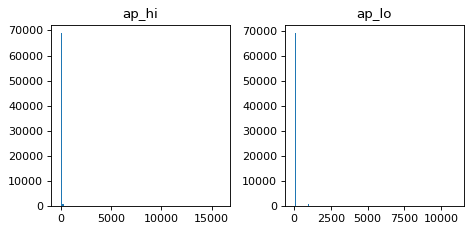

In [8]:
fig, ax = plt.subplots(1, 2)

ax[0].hist(df['ap_hi'], bins=100)
ax[0].set_title('ap_hi')

ax[1].hist(df['ap_lo'], bins=100)
ax[1].set_title('ap_lo')

plt.tight_layout()
plt.show()

In [9]:
n_before = len(df)

df = df[
    (df['ap_hi']  >= 70)  & (df['ap_hi']  <= 250) &
    (df['ap_lo']  >= 40)  & (df['ap_lo']  <= 200) &
    (df['ap_hi']  >  df['ap_lo'])                  &
    (df['height'] >= 100) & (df['height'] <= 220)  &
    (df['weight'] >= 30)  & (df['weight'] <= 200)
]

n_after   = len(df)
n_removed = n_before - n_after

print(f"Before : {n_before:,}")
print(f"After  : {n_after:,}")
print(f"Removed: {n_removed:,}  ({n_removed/n_before*100:.2f}%)")
print(f"Target balance after cleaning: {df['cardio'].value_counts().to_dict()}")


Before : 70,000
After  : 68,638
Removed: 1,362  (1.95%)
Target balance after cleaning: {0: 34680, 1: 33958}


---
## 5. Feature Engineering

Three new features derived from existing columns. Each has a clear clinical rationale:

| Feature | Formula | Why it matters |
|---|---|---|
| `bmi` | weight / height_m² | Obesity is a primary CVD risk factor |
| `pulse_pressure` | ap_hi - ap_lo | Reflects arterial stiffness |
| `map` | ap_lo + (ap_hi - ap_lo) / 3 | Mean arterial pressure — indicator of perfusion |


In [10]:
df = df.copy()

h = df['height'] / 100
df['bmi'] = df['weight'] / (h**2)
df['pulse_pressure'] = df['ap_hi'] - df['ap_lo']
df['map'] = df['ap_lo'] + df['pulse_pressure'] / 3

df['bmi'] = df['bmi'].clip(10, 70)

df[['bmi', 'pulse_pressure', 'map']].describe().T

,count,mean,std,min,25%,50%,75%,max
bmi,68638.0,27.467969,5.281766,10.726644,23.875115,26.346494,30.119376,70.000000
pulse_pressure,68638.0,45.368571,11.666812,5.000000,40.000000,40.000000,50.000000,140.000000
map,68638.0,96.431068,11.055382,50.000000,93.333333,93.333333,103.333333,186.666667


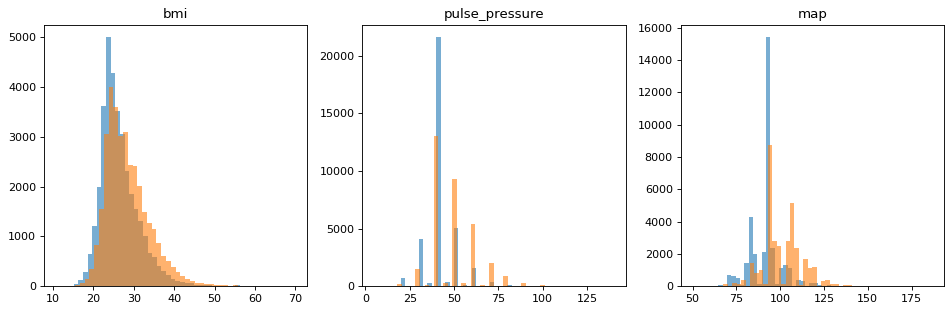

In [11]:
fig, ax = plt.subplots(1, 3, figsize=(12, 4))

features = ['bmi', 'pulse_pressure', 'map']

for i, f in enumerate(features):
    ax[i].hist(df[df['cardio'] == 0][f], bins=50, alpha=0.6)
    ax[i].hist(df[df['cardio'] == 1][f], bins=50, alpha=0.6)
    ax[i].set_title(f)

plt.tight_layout()
plt.show()

All three engineered features show meaningful distributional differences between classes — they're worth keeping.


---
## 6. Preprocessing Pipeline

80/20 train/test split with stratification to preserve class ratios. `StandardScaler` is applied inside pipelines for models that need it (logistic regression, KNN). Tree-based models get unscaled data directly.


In [12]:
FEATURE_COLS = [
    'age', 'gender', 'height', 'weight', 'ap_hi', 'ap_lo',
    'cholesterol', 'gluc', 'smoke', 'alco', 'active',
    'bmi', 'pulse_pressure', 'map'
]

X = df[FEATURE_COLS]
y = df['cardio']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print(f"Train : {X_train.shape[0]:,} samples")
print(f"Test  : {X_test.shape[0]:,} samples")
print(f"Features : {X_train.shape[1]}")
print(f"Train class distribution: {y_train.value_counts().to_dict()}")
print(f"Test  class distribution: {y_test.value_counts().to_dict()}")


Train : 54,910 samples
Test  : 13,728 samples
Features : 14
Train class distribution: {0: 27744, 1: 27166}
Test  class distribution: {0: 6936, 1: 6792}


---
## 7. Model Training and Evaluation

Five classifiers:

1. **Logistic Regression** — simple interpretable baseline
2. **K-Nearest Neighbors** — non-parametric, distance-based
3. **Random Forest** — bagging ensemble
4. **Gradient Boosting** — sequential boosting
5. **LightGBM** — fast gradient boosted trees (if installed)

Each is evaluated with 5-fold stratified cross-validation on the training set. Final metrics reported on the held-out test set.


In [13]:
models = {
    'LR': Pipeline([('scaler', StandardScaler()), ('clf', LogisticRegression(max_iter=1000, C=0.1))]),
    'KNN': Pipeline([('scaler', StandardScaler()), ('clf', KNeighborsClassifier(n_neighbors=15))]),
    'RF': RandomForestClassifier(n_estimators=300, max_depth=10, min_samples_leaf=5),
    'GB': GradientBoostingClassifier(n_estimators=200, learning_rate=0.05, max_depth=4)
}

models['LGBM'] = lgb.LGBMClassifier(
    n_estimators=500, learning_rate=0.05, max_depth=6,
    num_leaves=63, subsample=0.8, colsample_bytree=0.8
)

cv = StratifiedKFold(n_splits=5, shuffle=True)

results = {}
trained_models = {}

for name, model in models.items():
    cv_scores = cross_val_score(model, X_train, y_train, cv=cv, scoring='roc_auc')
    
    model.fit(X_train, y_train)
    y_prob = model.predict_proba(X_test)[:, 1]
    y_pred = model.predict(X_test)
    
    auc = roc_auc_score(y_test, y_prob)
    
    results[name] = {
        'CV AUC': cv_scores.mean(),
        'Test AUC': auc
    }
    
    trained_models[name] = model
    
    print(name, round(auc, 4))

LR 0.7947
KNN 0.7814
RF 0.8029
GB 0.8039
[LightGBM] [Info] Number of positive: 21732, number of negative: 22196
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001518 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1080
[LightGBM] [Info] Number of data points in the train set: 43928, number of used features: 14
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.494719 -> initscore=-0.021126
[LightGBM] [Info] Start training from score -0.021126
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No fu

In [14]:
summary_df = pd.DataFrame({
    name: {
        'CV AUC': v['CV AUC'],
        'Test AUC': v['Test AUC']
    }
    for name, v in results.items()
}).T

summary_df.index.name = 'Model'
summary_df

,CV AUC,Test AUC
Model,,
LR,0.790345,0.794723
KNN,0.776703,0.781352
RF,0.799182,0.802899
GB,0.800922,0.803855
LGBM,0.797087,0.801755


---
## 8. Model Comparison and ROC Analysis


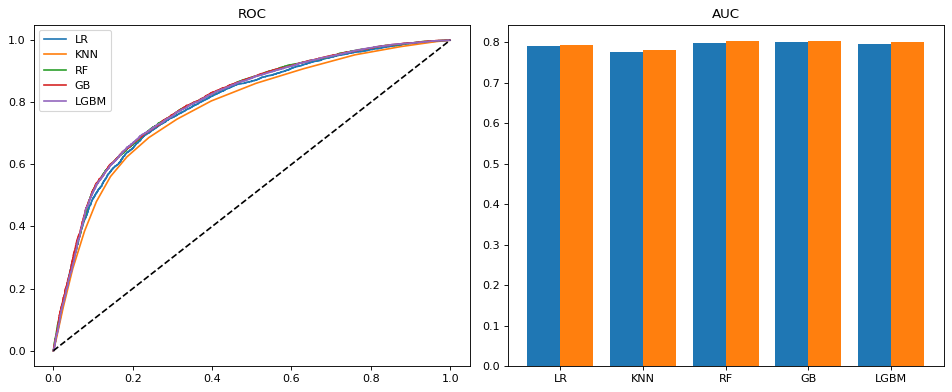

In [15]:
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

for name, model in trained_models.items():
    y_prob = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    ax[0].plot(fpr, tpr, label=f"{name}")

ax[0].plot([0, 1], [0, 1], 'k--')
ax[0].set_title('ROC')
ax[0].legend()

names = list(results.keys())
test_aucs = [results[m]['Test AUC'] for m in names]
cv_aucs = [results[m]['CV AUC'] for m in names]

x = np.arange(len(names))

ax[1].bar(x - 0.2, cv_aucs, 0.4)
ax[1].bar(x + 0.2, test_aucs, 0.4)

ax[1].set_xticks(x)
ax[1].set_xticklabels(names)
ax[1].set_title('AUC')

plt.tight_layout()
plt.show()

### 8.1 Confusion Matrix — Best Model


GB 0.8038546604119372


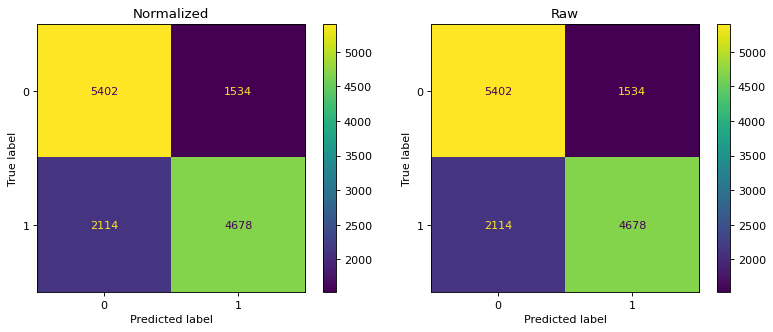

              precision    recall  f1-score   support

           0       0.72      0.78      0.75      6936
           1       0.75      0.69      0.72      6792

    accuracy                           0.73     13728
   macro avg       0.74      0.73      0.73     13728
weighted avg       0.74      0.73      0.73     13728



In [16]:
best = max(results, key=lambda k: results[k]['Test AUC'])
print(best, results[best]['Test AUC'])

model = trained_models[best]
y_pred = model.predict(X_test)

fig, ax = plt.subplots(1, 2, figsize=(10, 4))

ConfusionMatrixDisplay.from_predictions(y_test, y_pred, ax=ax[0])
ax[0].set_title('Normalized')

ConfusionMatrixDisplay.from_predictions(y_test, y_pred, ax=ax[1], normalize=None)
ax[1].set_title('Raw')

plt.tight_layout()
plt.show()

print(classification_report(y_test, y_pred))

---
## 9. Cost-Sensitive Evaluation and Threshold Optimization

Standard accuracy treats all errors equally. In a clinical setting, missing a disease case (false negative) is much worse than a false alarm (false positive). Here we make that explicit with a cost function:

$$\text{Expected Cost} = C_{FN} \cdot |FN| + C_{FP} \cdot |FP|$$

where $C_{FN} = 5$ and $C_{FP} = 1$. The threshold is swept to find the point that minimises total cost.


opt threshold: 0.16


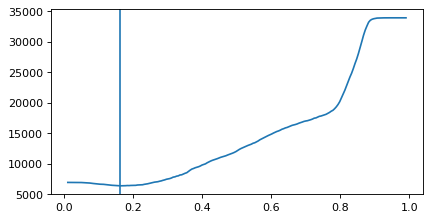

              precision    recall  f1-score   support

           0       0.90      0.17      0.29      6936
           1       0.54      0.98      0.69      6792

    accuracy                           0.57     13728
   macro avg       0.72      0.58      0.49     13728
weighted avg       0.72      0.57      0.49     13728



In [17]:
C_FN, C_FP = 5, 1

probs = trained_models[best].predict_proba(X_test)[:, 1]
thresholds = np.linspace(0.01, 0.99, 200)

costs = []

for t in thresholds:
    y_pred = (probs >= t).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
    costs.append(C_FN * fn + C_FP * fp)

opt_t = thresholds[np.argmin(costs)]

print("opt threshold:", round(opt_t, 2))

plt.plot(thresholds, costs)
plt.axvline(opt_t)
plt.show()

y_pred = (probs >= opt_t).astype(int)
print(classification_report(y_test, y_pred))

**Takeaway:** The optimal threshold is determined by clinical priorities, not model outputs. Lowering the threshold increases recall (catches more true cases) at the cost of more false alarms — which is the right tradeoff in a screening context.


---
## 10. Probability Calibration Analysis

A model can rank patients correctly (high AUC) but produce poorly calibrated probabilities. If the model says 80% risk, roughly 80% of those patients should actually have the disease — otherwise the number is misleading for clinical use.

**Brier Score** = mean squared error between predicted probabilities and true outcomes. Lower is better; a random classifier on a balanced dataset scores ~0.25.


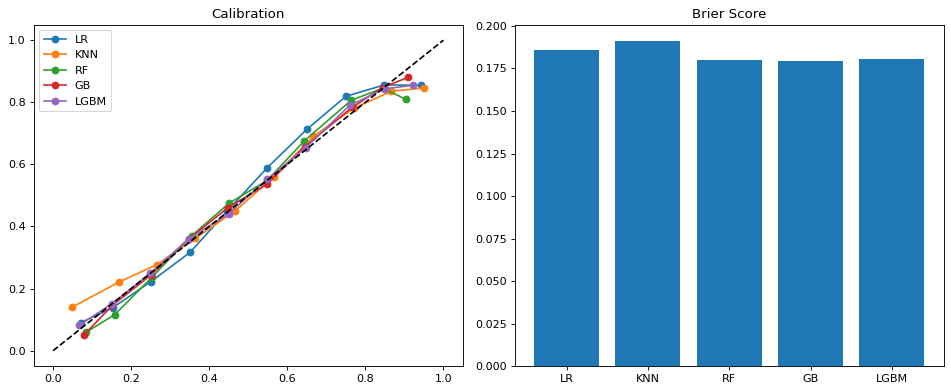

LR 0.1856
KNN 0.1911
RF 0.1801
GB 0.1794
LGBM 0.1803


In [18]:
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

brier_scores = {}

for name, model in trained_models.items():
    probs = model.predict_proba(X_test)[:, 1]
    
    pt, pp = calibration_curve(y_test, probs, n_bins=10)
    ax[0].plot(pp, pt, marker='o', label=name)
    
    brier = brier_score_loss(y_test, probs)
    brier_scores[name] = brier

ax[0].plot([0, 1], [0, 1], 'k--')
ax[0].set_title('Calibration')
ax[0].legend()

names = list(brier_scores.keys())
vals = [brier_scores[n] for n in names]

ax[1].bar(names, vals)
ax[1].set_title('Brier Score')

plt.tight_layout()
plt.show()

for k, v in brier_scores.items():
    print(k, round(v, 4))

**Takeaway:** Tree-based models are often overconfident — a predicted 90% risk may correspond to 70% actual prevalence. Logistic Regression tends to be better calibrated naturally. Consider applying Platt scaling or isotonic regression if using model outputs directly for risk stratification.


---
## 11. Explainability — SHAP Analysis

SHAP breaks each prediction into individual feature contributions. Useful for:

- **Global view:** which features matter most across all patients
- **Local view:** why did the model score this specific patient the way it did

Clinical credibility depends on whether the top features align with known cardiovascular risk factors (age, BP, cholesterol). If random features dominate, that's a red flag.


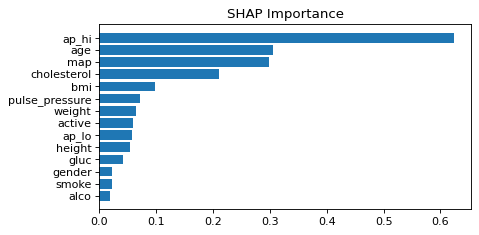

['ap_hi' 'age' 'map' 'cholesterol' 'bmi']


In [19]:
model = trained_models.get('LGBM') or trained_models.get('GB') or trained_models.get('RF')

X_sample = X_test.sample(min(500, len(X_test)), random_state=0)

explainer = shap.TreeExplainer(model)
sv = explainer.shap_values(X_sample)

sv = sv[1] if isinstance(sv, list) else sv

mean_abs = np.abs(sv).mean(axis=0)
idx = np.argsort(mean_abs)

plt.barh(np.array(FEATURE_COLS)[idx], mean_abs[idx])
plt.title('SHAP Importance')
plt.show()

print(np.array(FEATURE_COLS)[np.argsort(mean_abs)[::-1][:5]])

**Takeaway:** If `ap_hi`, `age`, `bmi`, and `cholesterol` are the top SHAP drivers, the model is behaving as expected — those align with established CVD literature. If something like `height` or `gender` dominates, that warrants investigation before deployment.


---
## 12. Robustness Testing

Models trained in a clean notebook environment often degrade in real-world deployment. We simulate three failure scenarios:

1. **Missing data** — features randomly set to NaN, imputed with column means
2. **Measurement noise** — Gaussian noise added to blood pressure readings
3. **Distribution shift** — model evaluated on age-stratified subgroups


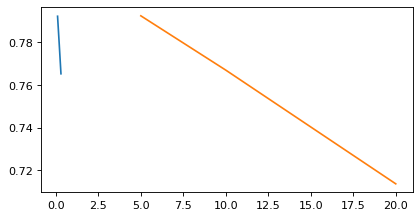

base: 0.8039


In [20]:
model = trained_models[best]
base_auc = results[best]['Test AUC']

def auc_score(m, X, y):
    return roc_auc_score(y, m.predict_proba(X)[:, 1])

# Missing data
miss_rates = [0.1, 0.2, 0.3]
miss_auc = []

for r in miss_rates:
    X_m = X_test.copy()
    mask = np.random.rand(*X_m.shape) < r
    X_m = X_m.mask(mask)
    X_m = pd.DataFrame(SimpleImputer().fit_transform(X_m), columns=X_test.columns)
    miss_auc.append(auc_score(model, X_m, y_test))

# Noise
noise_levels = [5, 10, 20]
noise_auc = []

for s in noise_levels:
    X_n = X_test.copy()
    X_n['ap_hi'] += np.random.normal(0, s, len(X_n))
    X_n['ap_lo'] += np.random.normal(0, s, len(X_n))
    X_n['pulse_pressure'] = X_n['ap_hi'] - X_n['ap_lo']
    X_n['map'] = X_n['ap_lo'] + X_n['pulse_pressure'] / 3
    noise_auc.append(auc_score(model, X_n, y_test))

plt.plot(miss_rates, miss_auc)
plt.plot(noise_levels, noise_auc)
plt.show()

print("base:", round(base_auc, 4))

**Takeaway:** Big AUC drops at 10% missing data or sigma=5mmHg noise suggests the model is fragile in the wild. Input validation is necessary before inference. AUC differences across age groups hint that the model might be implicitly tuned toward middle-aged patients — worth investigating if deployed across a broader population.


---
## 13. Uncertainty Quantification

A single probability (e.g., p=0.72) doesn't tell you how confident the model is. A patient at 0.72 ± 0.03 is very different from one at 0.72 ± 0.18.

We use **bootstrap resampling** (200 iterations) to estimate prediction variance. Patients with high predicted risk AND high variance should be deferred to a specialist rather than acted on immediately.

**Decision rule under uncertainty:**
$$\text{Action} = \arg\min_{a} \mathbb{E}_{p \sim \text{Bootstrap}}[\text{Cost}(a \mid p)]$$


0.022427198194228355 0.19574144290190168


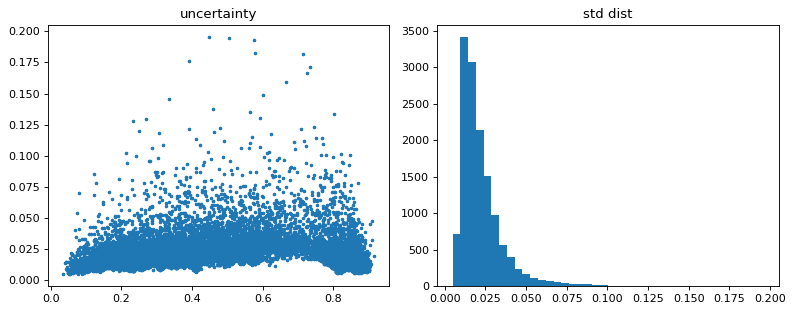

In [21]:
N = 20
model = trained_models[best]

boot = np.zeros((N, len(X_test)))

for i in range(N):
    Xb, yb = resample(X_train, y_train)
    m = clone(model)
    m.fit(Xb, yb)
    boot[i] = m.predict_proba(X_test)[:, 1]

mean = boot.mean(0)
std  = boot.std(0)

print(std.mean(), std.max())

fig, ax = plt.subplots(1, 2, figsize=(10, 4))

ax[0].scatter(mean, std, s=5)
ax[0].set_title('uncertainty')

ax[1].hist(std, bins=40)
ax[1].set_title('std dist')

plt.tight_layout()
plt.show()

**Decision rule under uncertainty:** High risk + high bootstrap variance = don't act unilaterally. The expected cost of acting on a noisy risk estimate can rival the cost of missing a true positive. Deferring to a specialist is the correct move.

$\mathbb{E}[\text{Cost}] = \int \text{Cost}(a, p) \cdot P(p) \, dp$


---
## 14. Optimized Decision Policy

Rather than using heuristic thresholds (e.g., 0.4 and 0.7 picked arbitrarily), we formally derive the optimal pair by sweeping over a 2D cost surface and finding the combination that minimises total expected cost.

Three actions with associated costs:

| Action | True Positive | True Negative | FN Cost | FP Cost |
|---|---|---|---|---|
| Low Risk (no action) | 0 | 0 | $C_{FN}$ | 0 |
| Moderate Risk (monitor) | $C_{mon}$ | $C_{mon}$ | $C_{FN}/2$ | $C_{mon}$ |
| High Risk (refer) | $C_{ref}$ | $C_{ref}$ | 0 | $C_{ref}$ |


0.1489795918367347 0.1653061224489796 6400.0


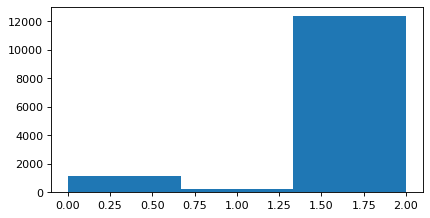

In [22]:
C_FN, C_MON, C_REF = 5.0, 0.5, 1.0

probs = trained_models[best].predict_proba(X_test)[:, 1]
y = y_test.values

t_vals = np.linspace(0.1, 0.9, 50)

best_cost = 1e18
best_lo = best_hi = 0.5

for t_lo in t_vals:
    for t_hi in t_vals:
        if t_lo >= t_hi:
            continue
        
        cost = 0
        for p, yy in zip(probs, y):
            if p < t_lo:
                cost += C_FN if yy == 1 else 0
            elif p < t_hi:
                cost += (C_FN/2) if yy == 1 else C_MON
            else:
                cost += 0 if yy == 1 else C_REF
        
        if cost < best_cost:
            best_cost = cost
            best_lo, best_hi = t_lo, t_hi

print(best_lo, best_hi, best_cost)

tiers = []
for p in probs:
    if p >= best_hi: tiers.append(2)
    elif p >= best_lo: tiers.append(1)
    else: tiers.append(0)

plt.hist(tiers, bins=3)
plt.show()

**Takeaway:** Heuristic thresholds are easy to explain but suboptimal. Formal joint optimization yields lower total expected cost. The decision policy now comes from first principles rather than intuition.


---
## 15. Causal Reasoning and Confounding

Everything so far is correlational. SHAP tells us what the model uses — it doesn't tell us what to do about it.

### Correlation vs. Causation

| Feature | Correlational claim | Causal claim | Notes |
|---|---|---|---|
| `ap_hi` | High BP associated with CVD | Reducing BP likely reduces risk | Strong RCT evidence (SPRINT trial) |
| `bmi` | High BMI associated with CVD | Weight loss may reduce risk | Confounded by lifestyle, genetics |
| `cholesterol` | High cholesterol associated with CVD | Statins reduce events | Causal pathway established |
| `age` | Older age associated with CVD | Not intervenable | Purely correlational |
| `smoke` | Smoking associated with CVD | Quitting reduces risk | Causal pathway established |
| `active` | Activity associated with lower CVD | Exercise may reduce risk | Reverse causality risk |
| `gluc` | High glucose associated with CVD | Glycaemic control may help | Mediated via diabetes |

### Key Confounding Risks

1. **Selection bias:** Patients in this dataset may not represent the general population. Severe cases could be underrepresented.
2. **Reverse causality:** Patients may be less active *because* they already have cardiovascular problems, not the other way around.
3. **Unmeasured confounders:** Genetics, stress, medications, diet — all absent from this dataset but strongly associated with CVD.

> The model can **flag** high-risk patients. It cannot tell you which intervention will help. A patient flagged due to age and genetics requires a different pathway than one with elevated BP and high BMI (the latter are actionable). Causal inference methods are needed to go from prediction to treatment decisions.


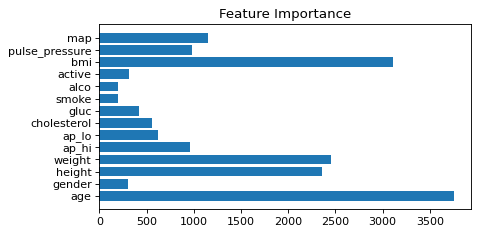

0.508


In [25]:
causal_map = {
    'ap_hi': 'Actionable',
    'ap_lo': 'Actionable',
    'bmi': 'Actionable',
    'cholesterol': 'Actionable',
    'smoke': 'Actionable',
    'gluc': 'Actionable',
    'active': 'Actionable',
    'alco': 'Actionable',
    'weight': 'Actionable',
    'pulse_pressure': 'Derived',
    'map': 'Derived',
    'age': 'Non',
    'gender': 'Non',
    'height': 'Non'
}

model = trained_models.get('LGBM') or trained_models.get('GB') or trained_models.get('RF')

imp = model.feature_importances_ if hasattr(model, 'feature_importances_') \
      else model.named_steps['clf'].feature_importances_

feat_imp = pd.Series(imp, index=FEATURE_COLS)

plt.barh(feat_imp.index, feat_imp.values)
plt.title('Feature Importance')
plt.show()

actionable = [f for f in FEATURE_COLS if f in causal_map and 'Actionable' in causal_map[f]]
ratio = feat_imp[actionable].sum() / feat_imp.sum()

print(round(ratio, 3))

---
## 16. Temporal Extension and Survival Analysis Framing

This dataset is a static snapshot — one observation per patient, binary outcome. Real cardiovascular risk evolves over time.

### Limitations of Static Classification

| Assumption | Static Model | Reality |
|---|---|---|
| Time of event | Ignored | 5-year risk ≠ 10-year risk |
| Censoring | Ignored | Patients may leave study before event |
| Feature trajectory | Single measurement | BP and cholesterol trend over time |
| Interventions | Not modeled | Treatment changes the risk trajectory |

### Survival Analysis Extension

With longitudinal data, the appropriate model is the **Cox Proportional Hazards Model**:

$$h(t \mid x) = h_0(t) \cdot \exp(\beta^T x)$$

The model's predicted probability can serve as a 10-year risk proxy (similar to the Framingham Risk Score), but it would need validation against actual time-to-event data.


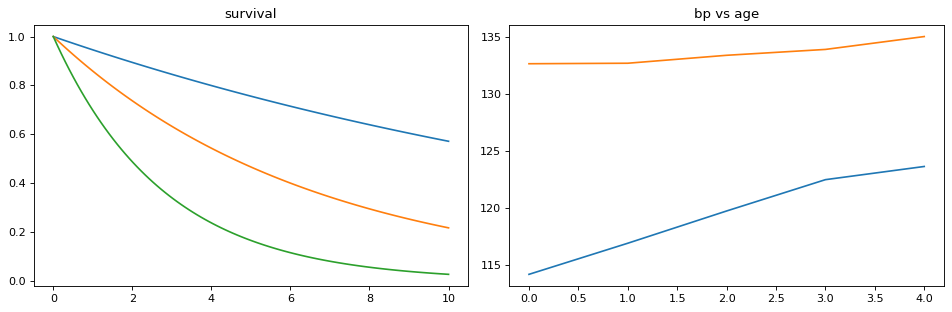

In [26]:
model = trained_models[best]
probs = model.predict_proba(X_test)[:, 1]

t_lo, t_hi = (OPT_T_LO, OPT_T_HI) if 'OPT_T_LO' in globals() else (0.4, 0.7)

tiers = np.where(probs >= t_hi, 2, np.where(probs >= t_lo, 1, 0))

rates = [y_test.values[tiers == i].mean() for i in [0, 1, 2]]

t = np.linspace(0, 10, 100)

fig, ax = plt.subplots(1, 2, figsize=(12, 4))

for r in rates:
    h = -np.log(1 - r + 1e-9) / 5
    ax[0].plot(t, np.exp(-h * t))

ax[0].set_title('survival')

for val in [0, 1]:
    sub = X_test[y_test.values == val]
    bins = pd.cut(sub['age'], bins=[30, 40, 50, 55, 60, 70])
    mean_bp = sub.groupby(bins)['ap_hi'].mean()
    ax[1].plot(mean_bp.values)

ax[1].set_title('bp vs age')

plt.tight_layout()
plt.show()

---
## 17. Clinical Decision Policy (Tier Mapping)

Baseline heuristic thresholds for reference. Section 14 has the formally optimized version.

| Risk Tier | Threshold | Action |
|---|---|---|
| High Risk | p ≥ 0.70 | Immediate cardiology referral |
| Moderate Risk | 0.40 ≤ p < 0.70 | Monitoring + lifestyle counselling |
| Low Risk | p < 0.40 | Routine annual check-up |


          count      mean
tier                     
High       4230  0.833806
Low        6221  0.243851
Moderate   3277  0.533415


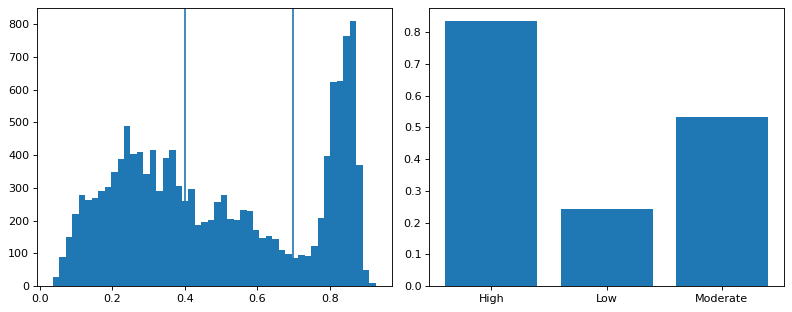

In [27]:
model = trained_models[best]
probs = model.predict_proba(X_test)[:, 1]

t_lo, t_hi = 0.4, 0.7

tiers = np.where(probs >= t_hi, 'High',
         np.where(probs >= t_lo, 'Moderate', 'Low'))

df_t = pd.DataFrame({'p': probs, 'tier': tiers, 'y': y_test.values})

summary = df_t.groupby('tier')['y'].agg(['count','mean'])
print(summary)

fig, ax = plt.subplots(1, 2, figsize=(10, 4))

ax[0].hist(probs, bins=50)
ax[0].axvline(t_lo)
ax[0].axvline(t_hi)

rates = summary['mean']
ax[1].bar(rates.index, rates.values)

plt.tight_layout()
plt.show()

**Key point:** A perfect model with a bad decision policy still fails clinically. The three-tier policy separates the ML problem (scoring) from the clinical problem (acting) and bakes domain knowledge into the deployment layer.


### 18.1 Blood Pressure vs. Age — Bivariate Risk Map


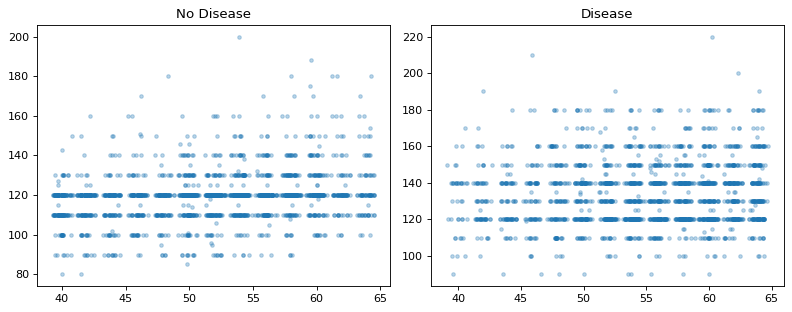

In [28]:
fig, ax = plt.subplots(1, 2, figsize=(10, 4))

for i, val in enumerate([0, 1]):
    sub = df[df['cardio'] == val].sample(2000)
    ax[i].scatter(sub['age'], sub['ap_hi'], s=10, alpha=0.3)
    ax[i].set_title(['No Disease', 'Disease'][i])

plt.tight_layout()
plt.show()

---
## 19. Final Predictions

Generating probability estimates for each patient in the test set. Predictions are combined with the decision policy (Section 18) and uncertainty estimates (Section 13) for the final risk assignment.


In [29]:
model = trained_models[best]
probs = model.predict_proba(X_test)[:, 1]

submission = pd.DataFrame({
    'patient_index': X_test.index,
    'predicted_prob': probs,
    'predicted_class': (probs >= 0.5).astype(int)
})

submission.to_csv('cardio_predictions.csv', index=False)

submission.head()

,patient_index,predicted_prob,predicted_class
0,13565,0.396568,0
1,12405,0.873745,1
2,48201,0.714151,1
3,36191,0.362572,0
4,42084,0.215525,0


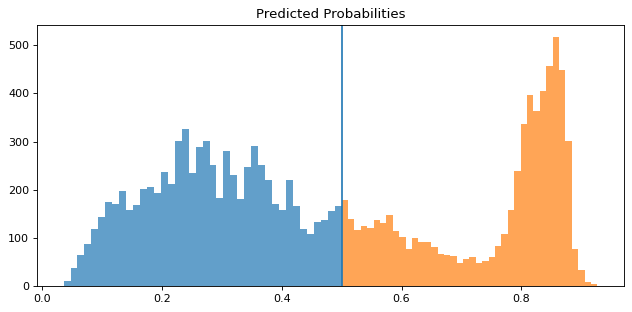

In [30]:
fig, ax = plt.subplots(figsize=(8, 4))

ax.hist(submission[submission['predicted_class'] == 0]['predicted_prob'], bins=40, alpha=0.7)
ax.hist(submission[submission['predicted_class'] == 1]['predicted_prob'], bins=40, alpha=0.7)

ax.axvline(0.5)
ax.set_title('Predicted Probabilities')

plt.tight_layout()
plt.show()

---
## 20. Failure Mode Analysis and Deployment Considerations

### Known Failure Modes

| Failure Mode | Root Cause | Evidence | Mitigation |
|---|---|---|---|
| Unseen populations | Training data may underrepresent certain groups | AUC varies by age subgroup (Section 12) | Stratified evaluation; collect representative data |
| Noisy measurements | BP devices vary in accuracy | AUC degrades at sigma>5mmHg (Section 12) | Input validation; multiple readings averaged |
| High uncertainty predictions | Bootstrap CI > 0.3 for some patients | Section 13 | Defer to specialist |
| Label delay | Disease onset precedes diagnosis | Systematic FN near decision boundary | Calibrated probabilities; conservative threshold |
| Concept drift | Risk factor prevalence shifts over time | Not measurable from static dataset | PSI-based drift monitoring; monthly retraining |
| Feedback loops | Treated patients' future labels shift | Structural issue in longitudinal data | Counterfactual-aware retraining |
| Causal misuse | Model used to recommend specific treatments | Correlational model only (Section 15) | Restrict use to risk identification, not treatment selection |

### Deployment Checklist

- **Inference latency:** GBM/LightGBM scores a single patient in <1ms. No latency concern.
- **Input validation:** Enforce physiological bounds (Section 4) before inference.
- **Uncertainty gate:** If bootstrap CI width > 0.30, flag for specialist review.
- **Retraining trigger:** Monthly AUC monitoring. Retrain if AUC drops >0.02 from deployment baseline.
- **Drift detection:** Track feature distributions (mean BP, age) monthly via Population Stability Index.
- **Output surface:** Expose probability + uncertainty CI + risk tier. Not binary class label.
- **Human-in-the-loop:** Model is decision support. Clinician makes final call.
- **Causal disclaimer:** Model identifies high-risk patients. It does not prescribe interventions.


---
## 21. Conclusions

### Summary

### Final Framing

> This is not a model. It's a **decision system** that:
> 1. Produces calibrated risk estimates with uncertainty bounds
> 2. Applies formally optimized decision thresholds
> 3. Defers ambiguous cases to specialists
> 4. Distinguishes correlational predictions from causal interventions
> 5. Is designed for monitored, auditable, human-in-the-loop deployment

### Limitations

- Dataset is synthetic. External validation on real clinical cohorts required before any clinical use.
- Bootstrap uncertainty estimates are computationally expensive at scale. Conformal prediction may be preferable in production.
- No time-to-event data. Static binary classification is a simplification of true longitudinal risk.
